# RNA3D-Predict — Dataset Curation

This notebook prepares the RNA 3D structure dataset for the RNA3D-Predict project.

## Objective

Curate experimentally determined Solo RNA structures from the RNAsolo² representative dataset into a clean development dataset for machine learning.

## Current curation criteria

- Solo RNA representatives from RNAsolo²
- Single-chain structures
- RNA length: 20–200 nucleotides
- Standard nucleotides only: A, U, G, C
- Complete C4′ coordinate coverage

The notebook performs dataset inspection and curation only.
Model training, sequence-similarity splitting, graph construction, and evaluation are handled in separate notebooks.

In [6]:
# ---------------------------------------------------------
# CELL 1 — Mount Google Drive and locate the raw dataset
# ---------------------------------------------------------
# Purpose:
#   Mount Google Drive and automatically locate the RNAsolo
#   ZIP file inside the project's Dataset folder.
#
# This avoids hard-coding the ZIP filename/path and makes
# the notebook more robust if the dataset is moved within
# the project folder.
# ---------------------------------------------------------

from google.colab import drive
from pathlib import Path

# Mount Google Drive.
drive.mount("/content/drive")

# Main project directory.
PROJECT_DIR = Path(
    "/content/drive/MyDrive/RNA 3D Structure Prediction"
)

# Folder containing our raw dataset.
DATASET_DIR = PROJECT_DIR / "Dataset"

# Find ZIP files inside the Dataset folder.
zip_files = list(DATASET_DIR.glob("*.zip"))

print("Project directory:")
print(PROJECT_DIR)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nZIP files found:")

for file in zip_files:
    print(file.name)

# Make sure exactly one raw ZIP was found.
assert len(zip_files) == 1, (
    f"Expected exactly 1 ZIP file, "
    f"but found {len(zip_files)}."
)

# Store the raw dataset path for the rest of the notebook.
RAW_ZIP_PATH = zip_files[0]

print("\nRaw dataset ZIP:")
print(RAW_ZIP_PATH)

print("\nZIP exists:", RAW_ZIP_PATH.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory:
/content/drive/MyDrive/RNA 3D Structure Prediction

Dataset directory:
/content/drive/MyDrive/RNA 3D Structure Prediction/Dataset

ZIP files found:
BGSU__R__All__A__1000_0__pdb_4_53.zip

Raw dataset ZIP:
/content/drive/MyDrive/RNA 3D Structure Prediction/Dataset/BGSU__R__All__A__1000_0__pdb_4_53.zip

ZIP exists: True


In [7]:
# ---------------------------------------------------------
# CELL 2 — Validate the raw PDB archive
# ---------------------------------------------------------
# Purpose:
#   Confirm that the raw RNAsolo ZIP file identified in
#   Cell 1 exists, can be opened, and contains the expected
#   PDB structures.
#
# This cell does not modify the archive.
# It only validates the raw input before parsing begins.
# ---------------------------------------------------------

import zipfile

# ---------------------------------------------------------
# Check that the ZIP path discovered in Cell 1 exists.
# ---------------------------------------------------------

assert RAW_ZIP_PATH.exists(), (
    f"Raw dataset ZIP was not found:\n{RAW_ZIP_PATH}"
)

print("Raw dataset found:")
print(RAW_ZIP_PATH)


# ---------------------------------------------------------
# Open the ZIP archive and inspect its contents.
# ---------------------------------------------------------

with zipfile.ZipFile(RAW_ZIP_PATH, "r") as z:

    all_files = z.namelist()


# ---------------------------------------------------------
# Keep only PDB files.
# ---------------------------------------------------------

pdb_files = [
    file_name
    for file_name in all_files
    if file_name.lower().endswith(".pdb")
]


# ---------------------------------------------------------
# Report archive statistics.
# ---------------------------------------------------------

print("\nTotal files in archive:", len(all_files))
print("PDB structures:", len(pdb_files))


# ---------------------------------------------------------
# Show a few example files to verify the expected naming
# convention before the parser is used.
# ---------------------------------------------------------

print("\nFirst 10 PDB files:")

for file_name in pdb_files[:10]:
    print(file_name)


# ---------------------------------------------------------
# Basic validation checks.
# ---------------------------------------------------------

assert len(pdb_files) > 0, (
    "No PDB files were found in the raw archive."
)

print("\nArchive validation: PASSED")

Raw dataset found:
/content/drive/MyDrive/RNA 3D Structure Prediction/Dataset/BGSU__R__All__A__1000_0__pdb_4_53.zip

Total files in archive: 1188
PDB structures: 1188

First 10 PDB files:
PDB_00006WLQ_1_A.pdb
PDB_00002KX8_1_A.pdb
PDB_00008ZAU_1_A.pdb
PDB_00004PQV_1_A.pdb
PDB_00002RRC_1_A.pdb
PDB_00008ZA0_1_C-D.pdb
PDB_00007BPG_1_G-H.pdb
PDB_00001CSL_1_A-B.pdb
PDB_00004JRD_1_B.pdb
PDB_00006IZP_1_A.pdb

Archive validation: PASSED


In [8]:
# ---------------------------------------------------------
# CELL 3 — Imports and project configuration
# ---------------------------------------------------------
# Purpose:
#   Import the Python libraries used throughout Notebook 1
#   and define the basic constants for RNA parsing/curation.
#
# Keeping imports and configuration together makes the notebook
# easier to understand and reproduce.
# ---------------------------------------------------------

import zipfile
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# RNA-specific configuration
# ---------------------------------------------------------

# Standard RNA nucleotides accepted by our V1 dataset.
STANDARD_RNA_BASES = {"A", "U", "G", "C"}

# Minimum and maximum RNA length for the V1 development dataset.
MIN_RNA_LENGTH = 20
MAX_RNA_LENGTH = 200

# Coordinate atom used for our coarse-grained representation.
# We will extract the C4' atom for each nucleotide.
TARGET_ATOM = "C4'"


print("Configuration loaded successfully.")
print("Accepted nucleotides:", STANDARD_RNA_BASES)
print("RNA length range:", f"{MIN_RNA_LENGTH}-{MAX_RNA_LENGTH} nt")
print("Target coordinate atom:", TARGET_ATOM)

Configuration loaded successfully.
Accepted nucleotides: {'G', 'U', 'A', 'C'}
RNA length range: 20-200 nt
Target coordinate atom: C4'


In [9]:
# ---------------------------------------------------------
# CELL 4 — Parse PDB filename metadata
# ---------------------------------------------------------
# Purpose:
#   Extract the PDB ID, model number, and chain information
#   encoded in each RNAsolo PDB filename.
#
# Example:
#   PDB_00006WLQ_1_A.pdb
#       PDB ID  → 6WLQ
#       Model   → 1
#       Chains  → A
#
#   PDB_00008ZA0_1_C-D.pdb
#       PDB ID  → 8ZA0
#       Model   → 1
#       Chains  → C-D
# ---------------------------------------------------------

def parse_pdb_filename(filename):
    """
    Parse an RNAsolo PDB filename.

    Parameters
    ----------
    filename : str
        Filename such as:
        PDB_00006WLQ_1_A.pdb

    Returns
    -------
    dict
        Parsed PDB ID, model, and chain information.
    """

    # Remove the .pdb extension.
    name = filename[:-4] if filename.lower().endswith(".pdb") else filename

    # Split the filename into its underscore-separated components.
    parts = name.split("_")

    # Validate the expected filename structure.
    if len(parts) < 4 or parts[0] != "PDB":
        raise ValueError(f"Unexpected PDB filename format: {filename}")

    # Extract the PDB identifier.
    # RNAsolo stores it after the "0000" prefix.
    pdb_id = parts[1].replace("0000", "", 1)

    # Extract the model number.
    model = int(parts[2])

    # Everything after the model represents the chain specification.
    chain_spec = "_".join(parts[3:])

    # Validate that the chain information is present.
    if not chain_spec:
        raise ValueError(f"Missing chain information: {filename}")

    return {
        "pdb_id": pdb_id,
        "model": model,
        "filename_chains": chain_spec
    }


# ---------------------------------------------------------
# Test the parser on representative filenames
# ---------------------------------------------------------
# We test several filename patterns before using the parser
# across all 1,188 structures.
# ---------------------------------------------------------

test_filenames = [
    "PDB_00006WLQ_1_A.pdb",
    "PDB_00008ZA0_1_C-D.pdb",
    "PDB_00001CSL_1_A-B.pdb",
    "PDB_00009G7C_5_A.pdb"
]

for filename in test_filenames:
    print(filename)
    print("→", parse_pdb_filename(filename))
    print()

PDB_00006WLQ_1_A.pdb
→ {'pdb_id': '6WLQ', 'model': 1, 'filename_chains': 'A'}

PDB_00008ZA0_1_C-D.pdb
→ {'pdb_id': '8ZA0', 'model': 1, 'filename_chains': 'C-D'}

PDB_00001CSL_1_A-B.pdb
→ {'pdb_id': '1CSL', 'model': 1, 'filename_chains': 'A-B'}

PDB_00009G7C_5_A.pdb
→ {'pdb_id': '9G7C', 'model': 5, 'filename_chains': 'A'}



In [10]:
# ---------------------------------------------------------
# CELL 5 — Parse one PDB structure
# ---------------------------------------------------------
# Purpose:
#   Read one PDB structure and extract the information needed
#   for dataset curation and later machine learning.
#
# The parser extracts:
#   - PDB ID and model
#   - chain information
#   - RNA sequence
#   - unique residue names
#   - non-standard residues
#   - atom count
#   - P atom coordinates
#   - C4' atom coordinates
#
# We keep the coordinates in the raw parsed result because
# they will later become the prediction target.
# ---------------------------------------------------------

def parse_pdb_structure(lines, filename):
    """
    Parse one RNAsolo PDB structure.

    Parameters
    ----------
    lines : list[str]
        Lines read from a PDB file.

    filename : str
        Original RNAsolo PDB filename.

    Returns
    -------
    dict
        Parsed structure metadata and coordinates.
    """

    # -----------------------------------------------------
    # Parse information encoded in the filename.
    # -----------------------------------------------------
    file_info = parse_pdb_filename(filename)

    pdb_id = file_info["pdb_id"]
    model = file_info["model"]

    # -----------------------------------------------------
    # Store residues separately for each chain.
    # -----------------------------------------------------
    chains = {}

    # Count all ATOM records.
    atom_count = 0

    # -----------------------------------------------------
    # Read ATOM records from the PDB.
    # -----------------------------------------------------
    for line in lines:

        # Ignore REMARK, TER, END, etc.
        if not line.startswith("ATOM"):
            continue

        atom_count += 1

        # Extract standard PDB fixed-width fields.
        atom_name = line[12:16].strip()
        residue_name = line[17:20].strip()
        chain_id = line[21].strip()

        residue_number = line[22:26].strip()
        insertion_code = line[26].strip()

        # Extract 3D coordinates.
        x = float(line[30:38])
        y = float(line[38:46])
        z = float(line[46:54])

        # Create chain container when first encountered.
        if chain_id not in chains:
            chains[chain_id] = {
                "residues": {}
            }

        chain = chains[chain_id]

        # Use residue number + insertion code as the
        # unique residue identifier.
        residue_key = (
            residue_number,
            insertion_code
        )

        # Create the residue container when needed.
        if residue_key not in chain["residues"]:
            chain["residues"][residue_key] = {
                "residue_name": residue_name,
                "atoms": {},
                "P": None,
                "C4prime": None
            }

        residue = chain["residues"][residue_key]

        # Store all atom coordinates.
        residue["atoms"][atom_name] = (x, y, z)

        # Store phosphate atom coordinate.
        if atom_name == "P":
            residue["P"] = (x, y, z)

        # PDB files can represent C4' as C4' or C4*.
        if atom_name in {"C4'", "C4*"}:
            residue["C4prime"] = (x, y, z)

    # -----------------------------------------------------
    # Convert parsed chains into ordered residue data.
    # -----------------------------------------------------
    chain_metadata = {}

    for chain_id, chain_data in chains.items():

        # Sort residues according to residue number.
        ordered_residues = sorted(
            chain_data["residues"].items(),
            key=lambda item: (
                int(item[0][0])
                if item[0][0].isdigit()
                else 0,
                item[0][1]
            )
        )

        sequence = []
        residue_names = []
        c4prime_coordinates = []
        p_coordinates = []

        for _, residue in ordered_residues:

            residue_name = residue["residue_name"]

            # Keep the original residue name.
            residue_names.append(residue_name)

            # The sequence is represented initially by the
            # residue names; standard/non-standard filtering
            # is handled explicitly below.
            sequence.append(residue_name)

            # Store coordinates, including None when missing.
            c4prime_coordinates.append(
                residue["C4prime"]
            )

            p_coordinates.append(
                residue["P"]
            )

        # Identify unusual residue types.
        unique_residue_names = sorted(
            set(residue_names)
        )

        nonstandard_residues = sorted(
            set(unique_residue_names) - STANDARD_RNA_BASES
        )

        # Construct a clean sequence only when all residues
        # are standard RNA bases.
        if all(
            residue in STANDARD_RNA_BASES
            for residue in residue_names
        ):
            clean_sequence = "".join(residue_names)
        else:
            clean_sequence = "".join(residue_names)

        chain_metadata[chain_id] = {
            "sequence": clean_sequence,
            "residue_names": residue_names,
            "unique_residue_names": unique_residue_names,
            "nonstandard_residues": nonstandard_residues,
            "num_nonstandard_types": len(nonstandard_residues),
            "c4prime_coordinates": c4prime_coordinates,
            "p_coordinates": p_coordinates,
            "num_residues": len(residue_names)
        }

    # -----------------------------------------------------
    # Return the complete parsed structure.
    # -----------------------------------------------------
    return {
        "file_name": filename,
        "pdb_id": pdb_id,
        "model": model,
        "chains": chain_metadata,
        "num_chains": len(chain_metadata),
        "atom_count": atom_count
    }

In [11]:
# ---------------------------------------------------------
# CELL 6 — Validate the improved PDB parser
# ---------------------------------------------------------
# Purpose:
#   Confirm that the parser extracts sequence, residue
#   information, and coordinate coverage correctly from
#   one known RNA structure before processing the entire
#   archive.
# ---------------------------------------------------------

sample_file = pdb_files[0]

# Read the sample PDB from the raw ZIP archive.
with zipfile.ZipFile(RAW_ZIP_PATH, "r") as z:

    with z.open(sample_file) as f:

        sample_lines = [
            line.decode(
                "utf-8",
                errors="replace"
            ).rstrip("\n")
            for line in f
        ]

# Parse the sample structure.
sample_result = parse_pdb_structure(
    sample_lines,
    sample_file
)

print("Sample file:", sample_file)
print("PDB ID:", sample_result["pdb_id"])
print("Model:", sample_result["model"])
print("Number of chains:", sample_result["num_chains"])
print("Atom count:", sample_result["atom_count"])

# Inspect each parsed chain.
for chain_id, chain_data in sample_result["chains"].items():

    print(f"\nChain: {chain_id}")
    print("Number of residues:", chain_data["num_residues"])

    print(
        "Sequence:",
        chain_data["sequence"][:100]
    )

    print(
        "Unique residue names:",
        chain_data["unique_residue_names"]
    )

    print(
        "Non-standard residues:",
        chain_data["nonstandard_residues"]
    )

    print(
        "Number of non-standard types:",
        chain_data["num_nonstandard_types"]
    )

    print(
        "C4' coverage:",
        sum(
            coord is not None
            for coord in chain_data["c4prime_coordinates"]
        ),
        "/",
        chain_data["num_residues"]
    )

    print(
        "P coverage:",
        sum(
            coord is not None
            for coord in chain_data["p_coordinates"]
        ),
        "/",
        chain_data["num_residues"]
    )

Sample file: PDB_00006WLQ_1_A.pdb
PDB ID: 6WLQ
Model: 1
Number of chains: 1
Atom count: 3124

Chain: A
Number of residues: 118
Sequence: GUCAUGAGUGCCAGCGUCAAGCCCCGGCUUGCUGGCCGGCAACCCUCCAACCGCGGUGGGGUGCCCCGGGUGAUGACCAGGUUGAGUAGCCGUGACGGCU
Unique residue names: ['A', 'C', 'G', 'U']
Non-standard residues: []
Number of non-standard types: 0
C4' coverage: 118 / 118
P coverage: 118 / 118


In [12]:
# ---------------------------------------------------------
# CELL 7 — Parse all PDB structures in the archive
# ---------------------------------------------------------
# Purpose:
#   Apply our validated PDB parser to every structure in the
#   RNAsolo archive.
#
# Output:
#   raw_records → one dictionary per PDB structure
#
# At this stage we are NOT filtering structures.
# We want to preserve the raw information first.
# ---------------------------------------------------------

raw_records = []

# Open the raw ZIP archive once.
with zipfile.ZipFile(RAW_ZIP_PATH, "r") as z:

    # Process every PDB file.
    for index, filename in enumerate(pdb_files, start=1):

        try:
            # Read the PDB file from the ZIP archive.
            with z.open(filename) as f:

                lines = [
                    line.decode(
                        "utf-8",
                        errors="replace"
                    ).rstrip("\n")
                    for line in f
                ]

            # Parse the complete structure.
            parsed = parse_pdb_structure(
                lines,
                filename
            )

            # Add the parsed structure to our raw dataset.
            raw_records.append(parsed)

        except Exception as e:

            # Record the error rather than stopping the
            # entire dataset-processing pipeline.
            print(
                f"Error processing {filename}: {e}"
            )

        # Show progress every 100 structures.
        if index % 100 == 0 or index == len(pdb_files):
            print(
                f"Processed {index}/{len(pdb_files)}"
            )


print("\nParsing complete.")

print(
    "Successfully parsed:",
    len(raw_records)
)

print(
    "Parsing failures:",
    len(pdb_files) - len(raw_records)
)

Processed 100/1188
Processed 200/1188
Processed 300/1188
Processed 400/1188
Processed 500/1188
Processed 600/1188
Processed 700/1188
Processed 800/1188
Processed 900/1188
Processed 1000/1188
Processed 1100/1188
Processed 1188/1188

Parsing complete.
Successfully parsed: 1188
Parsing failures: 0


In [13]:
# ---------------------------------------------------------
# CELL 8 — Build the raw metadata dataframe
# ---------------------------------------------------------
# Purpose:
#   Convert the nested parser output into a clean tabular
#   dataframe for dataset inspection and curation.
#
# Important:
#   We retain chain-level sequences and coordinates inside
#   nested columns so that no structural information is lost.
# ---------------------------------------------------------

metadata_records = []

for record in raw_records:

    # Get all chains present in this structure.
    chain_ids = list(record["chains"].keys())

    # -----------------------------------------------------
    # Collect structure-level chain information.
    # -----------------------------------------------------

    all_sequences = []
    all_residue_names = []
    all_c4prime = []
    all_p = []

    for chain_id in chain_ids:

        chain_data = record["chains"][chain_id]

        all_sequences.append(
            chain_data["sequence"]
        )

        all_residue_names.extend(
            chain_data["residue_names"]
        )

        all_c4prime.extend(
            chain_data["c4prime_coordinates"]
        )

        all_p.extend(
            chain_data["p_coordinates"]
        )

    # -----------------------------------------------------
    # Calculate structure-level residue statistics.
    # -----------------------------------------------------

    num_residues = len(all_residue_names)

    unique_residue_names = sorted(
        set(all_residue_names)
    )

    nonstandard_residues = sorted(
        set(unique_residue_names) - STANDARD_RNA_BASES
    )

    num_nonstandard_types = len(
        nonstandard_residues
    )

    # -----------------------------------------------------
    # Calculate coordinate coverage.
    # -----------------------------------------------------

    p_present = sum(
        coord is not None
        for coord in all_p
    )

    c4prime_present = sum(
        coord is not None
        for coord in all_c4prime
    )

    p_coverage = (
        p_present / num_residues
        if num_residues > 0
        else 0.0
    )

    c4prime_coverage = (
        c4prime_present / num_residues
        if num_residues > 0
        else 0.0
    )

    # -----------------------------------------------------
    # Store one row for the complete structure.
    # -----------------------------------------------------

    metadata_records.append({

        "file_name": record["file_name"],
        "pdb_id": record["pdb_id"],
        "model": record["model"],

        # Example: A, A-B, C-D
        "filename_chains": "_".join(chain_ids),

        # Actual chain IDs detected in the PDB.
        "pdb_chains": ",".join(chain_ids),

        "num_chains": record["num_chains"],

        "num_residues": num_residues,

        # For multi-chain structures this contains the
        # concatenated chain sequences. These structures
        # will later be filtered out for V1.
        "sequence": "".join(all_sequences),

        "unique_residue_names": ",".join(
            unique_residue_names
        ),

        "nonstandard_residues": ",".join(
            nonstandard_residues
        ),

        "num_nonstandard_types":
            num_nonstandard_types,

        "atom_count":
            record["atom_count"],

        "P_present":
            p_present,

        "C4prime_present":
            c4prime_present,

        "P_coverage":
            p_coverage,

        "C4prime_coverage":
            c4prime_coverage,

        # Keep detailed chain data for later processing.
        "chains_data":
            record["chains"]
    })


# Convert all records into a dataframe.
raw_df = pd.DataFrame(metadata_records)

print("Raw metadata shape:", raw_df.shape)

print("\nColumns:")
print(raw_df.columns.tolist())

print("\nFirst 5 structures:")
display(
    raw_df.head()
)

Raw metadata shape: (1188, 17)

Columns:
['file_name', 'pdb_id', 'model', 'filename_chains', 'pdb_chains', 'num_chains', 'num_residues', 'sequence', 'unique_residue_names', 'nonstandard_residues', 'num_nonstandard_types', 'atom_count', 'P_present', 'C4prime_present', 'P_coverage', 'C4prime_coverage', 'chains_data']

First 5 structures:


,file_name,pdb_id,model,filename_chains,pdb_chains,num_chains,num_residues,sequence,unique_residue_names,nonstandard_residues,num_nonstandard_types,atom_count,P_present,C4prime_present,P_coverage,C4prime_coverage,chains_data
0,PDB_00006WLQ_1_A.pdb,6WLQ,1,A,A,1,118,GUCAUGAGUGCCAGCGUCAAGCCCCGGCUUGCUGGCCGGCAACCCU...,"A,C,G,U",,0,3124,118,118,1.00000,1.0,{'A': {'sequence': 'GUCAUGAGUGCCAGCGUCAAGCCCCG...
1,PDB_00002KX8_1_A.pdb,2KX8,1,A,A,1,42,GGGAAAUGAGGCGCUGCAUGUGGCAGUCUGCCUUUCUUUCCC,"A,C,G,U",,0,1338,41,42,0.97619,1.0,{'A': {'sequence': 'GGGAAAUGAGGCGCUGCAUGUGGCAG...
2,PDB_00008ZAU_1_A.pdb,8ZAU,1,A,A,1,67,GCGGGCUGACCGACCCCCCGAGUUCGCUUGGGGACAACUAGACAUA...,"A,C,G,U",,0,1767,67,67,1.00000,1.0,{'A': {'sequence': 'GCGGGCUGACCGACCCCCCGAGUUCG...
3,PDB_00004PQV_1_A.pdb,4PQV,1,A,A,1,68,GGGUCAGAUCGGCGAAAGUCGCCACUUCGCCGAGGAGUGCAAUCUG...,"A,C,G,U",,0,1466,68,68,1.00000,1.0,{'A': {'sequence': 'GGGUCAGAUCGGCGAAAGUCGCCACU...
4,PDB_00002RRC_1_A.pdb,2RRC,1,A,A,1,20,GACCCCCACGGCGAGGUCCA,"A,C,G,U",,0,533,20,20,1.00000,1.0,"{'A': {'sequence': 'GACCCCCACGGCGAGGUCCA', 're..."


In [14]:
# ---------------------------------------------------------
# CELL 8 — Build the raw metadata dataframe
# ---------------------------------------------------------
# Purpose:
#   Convert the parsed structure dictionaries into a clean
#   pandas DataFrame for dataset-level quality analysis.
#
# Important:
#   We are NOT filtering anything yet.
#   This is our raw parsed dataset containing all 1,188
#   structures.
#
# The detailed chain information and coordinates are retained
# in the "chains_data" column so we don't lose information.
# ---------------------------------------------------------

metadata_records = []

# Process every successfully parsed structure.
for record in raw_records:

    # Get the chain IDs detected in this structure.
    chain_ids = list(record["chains"].keys())

    # Containers for structure-level information.
    all_sequences = []
    all_residue_names = []
    all_c4prime = []
    all_p = []

    # -----------------------------------------------------
    # Combine chain-level information.
    # -----------------------------------------------------
    for chain_id in chain_ids:

        chain_data = record["chains"][chain_id]

        all_sequences.append(
            chain_data["sequence"]
        )

        all_residue_names.extend(
            chain_data["residue_names"]
        )

        all_c4prime.extend(
            chain_data["c4prime_coordinates"]
        )

        all_p.extend(
            chain_data["p_coordinates"]
        )

    # -----------------------------------------------------
    # Calculate structure-level residue statistics.
    # -----------------------------------------------------

    num_residues = len(all_residue_names)

    unique_residue_names = sorted(
        set(all_residue_names)
    )

    nonstandard_residues = sorted(
        set(unique_residue_names) - STANDARD_RNA_BASES
    )

    num_nonstandard_types = len(
        nonstandard_residues
    )

    # -----------------------------------------------------
    # Calculate coordinate coverage.
    # -----------------------------------------------------

    p_present = sum(
        coord is not None
        for coord in all_p
    )

    c4prime_present = sum(
        coord is not None
        for coord in all_c4prime
    )

    p_coverage = (
        p_present / num_residues
        if num_residues > 0
        else 0.0
    )

    c4prime_coverage = (
        c4prime_present / num_residues
        if num_residues > 0
        else 0.0
    )

    # -----------------------------------------------------
    # Store one row per PDB structure.
    # -----------------------------------------------------

    metadata_records.append({

        # Basic structural identifiers.
        "file_name": record["file_name"],
        "pdb_id": record["pdb_id"],
        "model": record["model"],

        # Chain information.
        "filename_chains": "-".join(chain_ids),
        "pdb_chains": ",".join(chain_ids),
        "num_chains": record["num_chains"],

        # Sequence information.
        "num_residues": num_residues,
        "sequence": "".join(all_sequences),
        "unique_residue_names": ",".join(
            unique_residue_names
        ),
        "nonstandard_residues": ",".join(
            nonstandard_residues
        ),
        "num_nonstandard_types":
            num_nonstandard_types,

        # Atom and coordinate information.
        "atom_count": record["atom_count"],
        "P_present": p_present,
        "C4prime_present": c4prime_present,
        "P_coverage": p_coverage,
        "C4prime_coverage": c4prime_coverage,

        # Keep detailed chain-level data for future processing.
        "chains_data": record["chains"]
    })


# Convert the records into a DataFrame.
raw_df = pd.DataFrame(metadata_records)

# ---------------------------------------------------------
# Basic validation of the resulting DataFrame.
# ---------------------------------------------------------

print("Raw metadata shape:", raw_df.shape)

print("\nColumns:")
print(raw_df.columns.tolist())

print("\nFirst 5 structures:")
display(raw_df.head())

Raw metadata shape: (1188, 17)

Columns:
['file_name', 'pdb_id', 'model', 'filename_chains', 'pdb_chains', 'num_chains', 'num_residues', 'sequence', 'unique_residue_names', 'nonstandard_residues', 'num_nonstandard_types', 'atom_count', 'P_present', 'C4prime_present', 'P_coverage', 'C4prime_coverage', 'chains_data']

First 5 structures:


,file_name,pdb_id,model,filename_chains,pdb_chains,num_chains,num_residues,sequence,unique_residue_names,nonstandard_residues,num_nonstandard_types,atom_count,P_present,C4prime_present,P_coverage,C4prime_coverage,chains_data
0,PDB_00006WLQ_1_A.pdb,6WLQ,1,A,A,1,118,GUCAUGAGUGCCAGCGUCAAGCCCCGGCUUGCUGGCCGGCAACCCU...,"A,C,G,U",,0,3124,118,118,1.00000,1.0,{'A': {'sequence': 'GUCAUGAGUGCCAGCGUCAAGCCCCG...
1,PDB_00002KX8_1_A.pdb,2KX8,1,A,A,1,42,GGGAAAUGAGGCGCUGCAUGUGGCAGUCUGCCUUUCUUUCCC,"A,C,G,U",,0,1338,41,42,0.97619,1.0,{'A': {'sequence': 'GGGAAAUGAGGCGCUGCAUGUGGCAG...
2,PDB_00008ZAU_1_A.pdb,8ZAU,1,A,A,1,67,GCGGGCUGACCGACCCCCCGAGUUCGCUUGGGGACAACUAGACAUA...,"A,C,G,U",,0,1767,67,67,1.00000,1.0,{'A': {'sequence': 'GCGGGCUGACCGACCCCCCGAGUUCG...
3,PDB_00004PQV_1_A.pdb,4PQV,1,A,A,1,68,GGGUCAGAUCGGCGAAAGUCGCCACUUCGCCGAGGAGUGCAAUCUG...,"A,C,G,U",,0,1466,68,68,1.00000,1.0,{'A': {'sequence': 'GGGUCAGAUCGGCGAAAGUCGCCACU...
4,PDB_00002RRC_1_A.pdb,2RRC,1,A,A,1,20,GACCCCCACGGCGAGGUCCA,"A,C,G,U",,0,533,20,20,1.00000,1.0,"{'A': {'sequence': 'GACCCCCACGGCGAGGUCCA', 're..."


In [15]:
# ---------------------------------------------------------
# CELL 9 — Raw dataset quality summary
# ---------------------------------------------------------
# Purpose:
#   Perform the main quality checks on all 1,188 parsed
#   RNA structures before applying any filtering rules.
#
# We inspect:
#   1. Dataset size
#   2. RNA length distribution
#   3. Number of chains
#   4. Non-standard residues
#   5. P atom coverage
#   6. C4' atom coverage
#
# This cell only reports the dataset properties.
# It does NOT remove or modify any structures.
# ---------------------------------------------------------

print("==============================================")
print("RAW DATASET QUALITY SUMMARY")
print("==============================================")

# ---------------------------------------------------------
# Basic dataset size
# ---------------------------------------------------------

print("\nTotal structures:", len(raw_df))

print(
    "Unique PDB IDs:",
    raw_df["pdb_id"].nunique()
)

print(
    "Total columns:",
    len(raw_df.columns)
)


# ---------------------------------------------------------
# RNA length statistics
# ---------------------------------------------------------

print("\n=== RNA LENGTH ===")

print(
    raw_df["num_residues"].describe()
)


# ---------------------------------------------------------
# Number of chains
# ---------------------------------------------------------

print("\n=== NUMBER OF CHAINS ===")

print(
    raw_df["num_chains"]
    .value_counts()
    .sort_index()
)


# ---------------------------------------------------------
# Non-standard residues
# ---------------------------------------------------------

print("\n=== NON-STANDARD RESIDUES ===")

print(
    "Structures with non-standard residues:",
    (
        raw_df["num_nonstandard_types"] > 0
    ).sum()
)

# Show the structures containing unusual residues.
nonstandard_df = raw_df[
    raw_df["num_nonstandard_types"] > 0
][
    [
        "file_name",
        "pdb_id",
        "num_residues",
        "unique_residue_names",
        "nonstandard_residues"
    ]
]

if len(nonstandard_df) > 0:
    display(nonstandard_df)


# ---------------------------------------------------------
# Phosphorus atom coverage
# ---------------------------------------------------------

print("\n=== P ATOM COVERAGE ===")

print(
    raw_df["P_coverage"].describe()
)

print(
    "Structures with full P coverage:",
    (
        raw_df["P_coverage"] == 1.0
    ).sum()
)


# ---------------------------------------------------------
# C4' atom coverage
# ---------------------------------------------------------

print("\n=== C4' ATOM COVERAGE ===")

print(
    raw_df["C4prime_coverage"].describe()
)

print(
    "Structures with full C4' coverage:",
    (
        raw_df["C4prime_coverage"] == 1.0
    ).sum()
)

RAW DATASET QUALITY SUMMARY

Total structures: 1188
Unique PDB IDs: 1143
Total columns: 17

=== RNA LENGTH ===
count    1188.000000
mean       69.352694
std       179.868456
min         1.000000
25%        18.000000
50%        28.000000
75%        55.250000
max      2891.000000
Name: num_residues, dtype: float64

=== NUMBER OF CHAINS ===
num_chains
1    821
2    352
3      9
4      5
8      1
Name: count, dtype: int64

=== NON-STANDARD RESIDUES ===
Structures with non-standard residues: 2


,file_name,pdb_id,num_residues,unique_residue_names,nonstandard_residues
73,PDB_00006E1T_1_A.pdb,6E1T,33,"A,C,G,N,U",N
840,PDB_00004RGE_1_C.pdb,4RGE,55,"A,C,DU,G,U",DU



=== P ATOM COVERAGE ===
count    1188.000000
mean        0.990473
std         0.026445
min         0.833333
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: P_coverage, dtype: float64
Structures with full P coverage: 986

=== C4' ATOM COVERAGE ===
count    1188.000000
mean        0.994552
std         0.071097
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: C4prime_coverage, dtype: float64
Structures with full C4' coverage: 1170


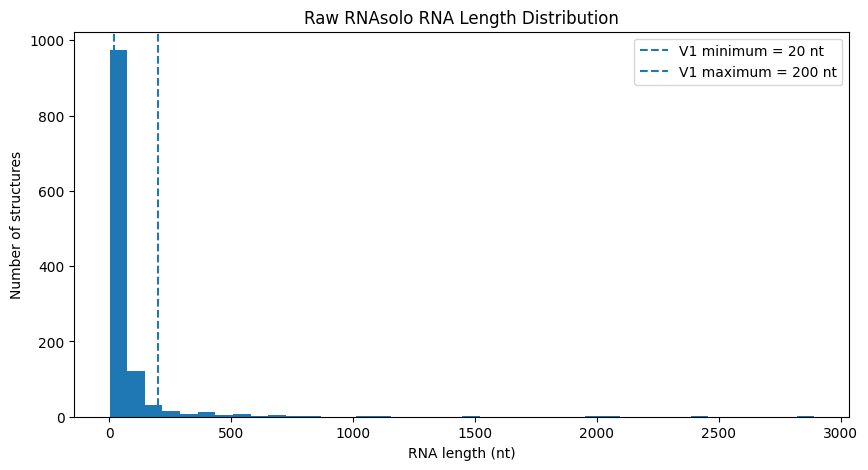

In [16]:
# ---------------------------------------------------------
# CELL 10 — Visualize the raw RNA length distribution
# ---------------------------------------------------------
# Purpose:
#   Visualize how RNA lengths are distributed across all
#   1,188 structures.
#
# Why:
#   The raw dataset contains structures ranging from very
#   short RNAs to extremely long RNAs. This visualization
#   helps justify the practical 20–200 nt scope used for V1.
#
# This cell only visualizes the raw dataset.
# It does NOT filter any structures.
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

# Plot the distribution of RNA lengths.
plt.hist(
    raw_df["num_residues"],
    bins=40
)

# Mark our proposed V1 curation range.
plt.axvline(
    MIN_RNA_LENGTH,
    linestyle="--",
    label=f"V1 minimum = {MIN_RNA_LENGTH} nt"
)

plt.axvline(
    MAX_RNA_LENGTH,
    linestyle="--",
    label=f"V1 maximum = {MAX_RNA_LENGTH} nt"
)

plt.xlabel("RNA length (nt)")
plt.ylabel("Number of structures")
plt.title("Raw RNAsolo RNA Length Distribution")

plt.legend()

plt.show()

In [17]:
# ---------------------------------------------------------
# CELL 10B — Summarize structures within the V1 length range
# ---------------------------------------------------------
# Purpose:
#   Quantify how many raw structures fall within our proposed
#   20–200 nucleotide development range.
#
# This is a diagnostic only; the actual filtering happens
# later in the curation cell.
# ---------------------------------------------------------

within_length_range = (
    (raw_df["num_residues"] >= MIN_RNA_LENGTH) &
    (raw_df["num_residues"] <= MAX_RNA_LENGTH)
)

print(
    f"Structures between {MIN_RNA_LENGTH} and "
    f"{MAX_RNA_LENGTH} nt:",
    within_length_range.sum()
)

print(
    "Percentage of raw dataset:",
    f"{within_length_range.mean() * 100:.2f}%"
)

Structures between 20 and 200 nt: 768
Percentage of raw dataset: 64.65%


In [18]:
# ---------------------------------------------------------
# CELL 11 — Apply the V1 dataset curation rules
# ---------------------------------------------------------
# Purpose:
#   Create the first curated RNA3D-Predict dataset from the
#   complete 1,188-structure raw dataset.
#
# A structure is retained only if ALL four conditions hold:
#
#   1. It contains exactly one RNA chain.
#   2. Its length is between 20 and 200 nucleotides.
#   3. It contains only standard RNA bases: A, U, G, C.
#   4. Every nucleotide has a C4' coordinate.
#
# IMPORTANT:
#   This cell creates a NEW dataframe called curated_v1.
#   raw_df remains unchanged.
# ---------------------------------------------------------


# ---------------------------------------------------------
# Rule 1 — Single-chain structures
# ---------------------------------------------------------
single_chain_mask = (
    raw_df["num_chains"] == 1
)


# ---------------------------------------------------------
# Rule 2 — RNA length between 20 and 200 nt
# ---------------------------------------------------------
length_mask = (
    (raw_df["num_residues"] >= MIN_RNA_LENGTH) &
    (raw_df["num_residues"] <= MAX_RNA_LENGTH)
)


# ---------------------------------------------------------
# Rule 3 — Standard RNA bases only
# ---------------------------------------------------------
standard_residue_mask = (
    raw_df["num_nonstandard_types"] == 0
)


# ---------------------------------------------------------
# Rule 4 — Complete C4' coordinate coverage
# ---------------------------------------------------------
c4prime_mask = (
    raw_df["C4prime_coverage"] == 1.0
)


# ---------------------------------------------------------
# Combine all four criteria
# ---------------------------------------------------------
curation_mask = (
    single_chain_mask &
    length_mask &
    standard_residue_mask &
    c4prime_mask
)


# Create the curated V1 dataset.
curated_v1 = raw_df[
    curation_mask
].copy()


# ---------------------------------------------------------
# Report the effect of each curation step
# ---------------------------------------------------------

print("==============================================")
print("V1 DATASET CURATION")
print("==============================================")

print(
    "Raw structures:",
    len(raw_df)
)

print(
    "Single-chain structures:",
    single_chain_mask.sum()
)

print(
    f"Structures in {MIN_RNA_LENGTH}–{MAX_RNA_LENGTH} nt range:",
    length_mask.sum()
)

print(
    "Structures with standard A/U/G/C only:",
    standard_residue_mask.sum()
)

print(
    "Structures with complete C4' coverage:",
    c4prime_mask.sum()
)

print(
    "\nFinal curated V1 structures:",
    len(curated_v1)
)

print(
    "Percentage retained:",
    f"{len(curated_v1) / len(raw_df) * 100:.2f}%"
)

V1 DATASET CURATION
Raw structures: 1188
Single-chain structures: 821
Structures in 20–200 nt range: 768
Structures with standard A/U/G/C only: 1186
Structures with complete C4' coverage: 1170

Final curated V1 structures: 536
Percentage retained: 45.12%


In [19]:
# ---------------------------------------------------------
# CELL 12 — Curation audit and cumulative filtering
# ---------------------------------------------------------
# Purpose:
#   Show how many structures remain after applying the
#   curation rules one after another.
#
# This gives us a transparent record of how the original
# 1,188 structures became the final 536 candidates.
#
# The raw_df dataframe is NOT modified.
# ---------------------------------------------------------

# ---------------------------------------------------------
# Apply the filters cumulatively
# ---------------------------------------------------------

step_1 = raw_df[
    single_chain_mask
].copy()

step_2 = step_1[
    length_mask.loc[step_1.index]
].copy()

step_3 = step_2[
    standard_residue_mask.loc[step_2.index]
].copy()

step_4 = step_3[
    c4prime_mask.loc[step_3.index]
].copy()


# ---------------------------------------------------------
# Build a compact audit table
# ---------------------------------------------------------

curation_audit = pd.DataFrame({
    "stage": [
        "Raw dataset",
        "Single-chain",
        "Single-chain + 20–200 nt",
        " + standard A/U/G/C",
        " + complete C4' coverage"
    ],

    "structures_remaining": [
        len(raw_df),
        len(step_1),
        len(step_2),
        len(step_3),
        len(step_4)
    ]
})


# Calculate percentage retained relative to the raw dataset.
curation_audit["percentage_of_raw"] = (
    curation_audit["structures_remaining"]
    / len(raw_df)
    * 100
)


# Calculate how many structures were removed at each stage.
curation_audit["removed_from_previous_stage"] = [
    0,
    len(raw_df) - len(step_1),
    len(step_1) - len(step_2),
    len(step_2) - len(step_3),
    len(step_3) - len(step_4)
]


# Display the audit table.
display(curation_audit)

,stage,structures_remaining,percentage_of_raw,removed_from_previous_stage
0,Raw dataset,1188,100.000000,0
1,Single-chain,821,69.107744,367
2,Single-chain + 20–200 nt,548,46.127946,273
3,+ standard A/U/G/C,546,45.959596,2
4,+ complete C4' coverage,536,45.117845,10


In [20]:
# ---------------------------------------------------------
# CELL 13 — Final curated V1 dataset quality summary
# ---------------------------------------------------------
# Purpose:
#   Perform one final quality check on the 536 structures
#   that passed all V1 curation criteria.
#
# This is our handoff checkpoint from:
#   Dataset Curation
# to:
#   Dataset Splitting and Redundancy Analysis
#
# No further filtering is performed here.
# ---------------------------------------------------------

print("==============================================")
print("CURATED V1 DATASET SUMMARY")
print("==============================================")

# ---------------------------------------------------------
# Dataset size
# ---------------------------------------------------------

print("\nTotal curated structures:",
      len(curated_v1))

print(
    "Unique PDB IDs:",
    curated_v1["pdb_id"].nunique()
)


# ---------------------------------------------------------
# RNA length statistics
# ---------------------------------------------------------

print("\n=== RNA LENGTH ===")

print(
    curated_v1["num_residues"].describe()
)


# ---------------------------------------------------------
# Chain information
# ---------------------------------------------------------

print("\n=== CHAINS ===")

print(
    curated_v1["num_chains"]
    .value_counts()
    .sort_index()
)


# ---------------------------------------------------------
# Residue validity
# ---------------------------------------------------------

print("\n=== RESIDUE VALIDITY ===")

print(
    "Structures with non-standard residues:",
    (
        curated_v1["num_nonstandard_types"] > 0
    ).sum()
)

print(
    "Unique residue types present:",
    sorted(
        set(
            ",".join(
                curated_v1["unique_residue_names"]
                .dropna()
                .tolist()
            ).split(",")
        )
    )
)


# ---------------------------------------------------------
# C4' coordinate completeness
# ---------------------------------------------------------

print("\n=== C4' COORDINATE COVERAGE ===")

print(
    "Structures with complete C4' coverage:",
    (
        curated_v1["C4prime_coverage"] == 1.0
    ).sum()
)

print(
    "Minimum C4' coverage:",
    curated_v1["C4prime_coverage"].min()
)


# ---------------------------------------------------------
# Sequence sanity check
# ---------------------------------------------------------

print("\n=== SEQUENCE SANITY CHECK ===")

invalid_sequences = []

for idx, sequence in curated_v1["sequence"].items():

    # Find any nucleotide outside A/U/G/C.
    invalid_bases = set(sequence) - STANDARD_RNA_BASES

    if invalid_bases:
        invalid_sequences.append(
            (idx, invalid_bases)
        )

print(
    "Sequences containing invalid bases:",
    len(invalid_sequences)
)


# ---------------------------------------------------------
# Exact duplicate sequence count
# ---------------------------------------------------------
# We are NOT removing duplicates here.
# We are only recording them for Notebook 2.
# ---------------------------------------------------------

sequence_counts = (
    curated_v1["sequence"]
    .value_counts()
)

duplicate_sequence_groups = (
    sequence_counts[sequence_counts > 1]
)

duplicate_structures = (
    duplicate_sequence_groups.sum()
)


print("\n=== SEQUENCE DUPLICATION ===")

print(
    "Unique sequences:",
    sequence_counts.size
)

print(
    "Exact duplicate sequence groups:",
    len(duplicate_sequence_groups)
)

print(
    "Structures belonging to duplicate groups:",
    duplicate_structures
)

CURATED V1 DATASET SUMMARY

Total curated structures: 536
Unique PDB IDs: 527

=== RNA LENGTH ===
count    536.000000
mean      54.695896
std       37.401170
min       20.000000
25%       27.000000
50%       41.000000
75%       71.000000
max      200.000000
Name: num_residues, dtype: float64

=== CHAINS ===
num_chains
1    536
Name: count, dtype: int64

=== RESIDUE VALIDITY ===
Structures with non-standard residues: 0
Unique residue types present: ['A', 'C', 'G', 'U']

=== C4' COORDINATE COVERAGE ===
Structures with complete C4' coverage: 536
Minimum C4' coverage: 1.0

=== SEQUENCE SANITY CHECK ===
Sequences containing invalid bases: 0

=== SEQUENCE DUPLICATION ===
Unique sequences: 503
Exact duplicate sequence groups: 26
Structures belonging to duplicate groups: 59


# Handoff to Dataset Splitting

The curated V1 candidate dataset contains 536 RNA structures.

All structures satisfy the predefined structural curation criteria:
- single-chain RNA
- 20–200 nucleotides
- standard A/C/G/U residues
- complete C4′ coordinate coverage

Exact sequence duplicates are retained at this stage because they may represent
different experimentally determined structures of the same RNA sequence.

The next notebook will address:
- sequence-group construction
- redundancy control
- train/validation/test splitting
- leakage prevention

No model training or graph construction is performed in this notebook.